# Analyze grid search results

In [1]:
%matplotlib ipympl

import pickle
import jax
import jax.numpy as jnp
import os
import matplotlib.pyplot as plt
import matplotlib.image as mp_img

jax.config.update("jax_enable_x64", True)
jnp.set_printoptions(linewidth=2**20)

In [ ]:
dir_name = "../../scripts/grid_data"
files = os.listdir(dir_name)
pickle_files = [f for f in files if ".pickle" in f]

data = []
for pickle_name in pickle_files:
    with open(f"{dir_name}/{pickle_name}", "rb") as f:
        data.append(pickle.load(f))
        data[-1]["name"] = pickle_name.split("_")[0]  # grab number

# only include "reasonable" angular velocity tracking
data = [elem for elem in data if elem["omega_err"] < 3.0]
    
sdata = sorted(data, key=lambda d: d["tot_err"])
# sdata = sorted(data, key=lambda d: d["tot_err_4"])
# sdata = sorted(data, key=lambda d: d["omega_err"])
# sdata = sorted(data, key=lambda d: jnp.sum(d["omega_diff"][:, 1]**2) + 1e-1 * jnp.sum(d["acc_diff"][:, 1]**2))
# sdata = sorted(data, key=lambda d: jnp.sum(d["omega_diff"][:, 1]**4) + 1e-3 * jnp.sum(d["acc_diff"][:, 1]**4))
# sdata = sorted(data, key=lambda d: jnp.sum(d["omega_diff"][:, 1]**2) + 5e-2 * jnp.sum(d["acc_diff"][:, 1]**2))
# sdata = sorted(data, key=lambda d: jnp.square(d["acc_err"] - d["omega_err"]) + jnp.square(d["tot_err"]))

In [59]:
def pprint(d: dict) -> None:
    for key, val in d.items():
        if key == "weights":
            print(
                f"lin_dyn: {val.lin_dyn}\n"
                f"omega: {val.omega}\n"
                f"alpha_acc: {val.alpha_acc}\n"
                f"alpha_omega: {val.alpha_omega}\n"
                f"control: {val.control}"
            )
        else:
            print(f'{key}: {str(val).replace("\n", " ")}')

In [60]:
plt.close("all")

lin_dyn: [100000. 100000. 100000.]
omega: [500000. 500000. 500000.]
alpha_acc: [1.]
alpha_omega: [1.]
control: [0.1 0.1 0.1 0.1 0.1 0.1]
cost_terms: CostTerms(leg_pos_cost=QuarticCost(coeffs=Array([[3.90625000e+01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],        [7.71604938e+01, 0.00000000e+00, 3.75000000e+01, 1.00000000e+01, 1.00000000e+00],        [7.91666667e+03, 0.00000000e+00, 7.91666667e+01, 4.08333333e+01, 8.00000000e+00],        [9.39625000e+06, 0.00000000e+00, 1.97916667e+03, 3.25833333e+02, 3.20000000e+01]], dtype=float64), knots=Array([0. , 0.4, 0.7, 0.9, 1. ], dtype=float64), low=Array(1.21041, dtype=float64), high=Array(1.72001, dtype=float64), center=Array(1.46250601, dtype=float64)), leg_vel_cost=QuarticCost(coeffs=Array([[4.16493128e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],        [3.35459184e+03, 0.00000000e+00, 1.22448980e+01, 5.71428571e+00, 1.00000000e+00],        [2.28030612e+06, 0.00000000e+00, 8.17346939e+02, 1.

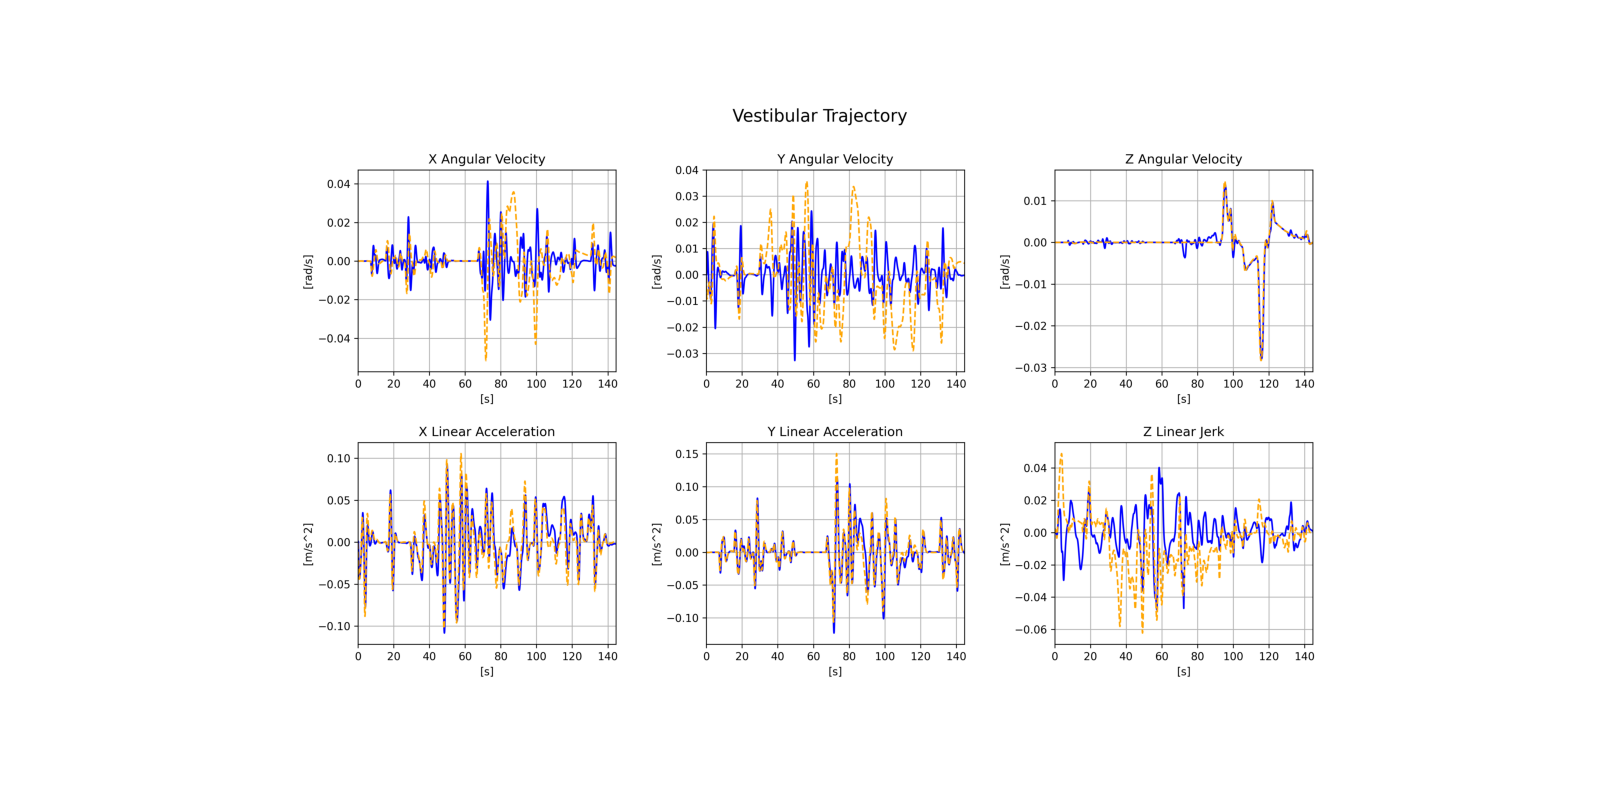

In [61]:
# idx = 11  # for tot_err_4, and maybe tot_err
idx = 0
pprint(sdata[idx])

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 8))
img = mp_img.imread(f"{dir_name}/{sdata[idx]["name"]}_vestibular.png")
ax.imshow(img)
ax.axis("off")
plt.show()